# Heart Disease Prediction Using Machine Learning

## Project Category
Classification

---

## Objective

The objective of this project is to predict whether a patient has heart disease based on medical attributes using machine learning classification algorithms.

This project aims to:
- analyze relationships between medical variables,
- identify important risk factors,
- compare multiple classification algorithms,
- evaluate model performance using classification metrics.

---

## Dataset Information

The dataset contains patient health information including:
- age
- sex
- chest pain type
- resting blood pressure
- cholesterol
- maximum heart rate
- exercise induced angina
- and other medical measurements.

### Target Variable
- `target`
    - 0 → No Heart Disease
    - 1 → Heart Disease

---

## Algorithms Used

The following machine learning algorithms will be compared:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- Gradient Boosting Classifier
- XGBoost Classifier

---

## Evaluation Metrics

Model performance will be evaluated using:

- Accuracy Score
- Precision
- Recall
- F1 Score
- Confusion Matrix

---

## Project Workflow

1. Data Understanding
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Model Building
5. Model Evaluation
6. Model Comparison
7. Conclusion

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving heart.csv to heart.csv


In [ ]:
import pandas as pd

df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [ ]:
df = pd.read_csv(
    "heart.csv",
    encoding="latin-1")

In [ ]:
print(df.shape)

df.info()

df.isnull().sum()

(1025, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


**EDA**

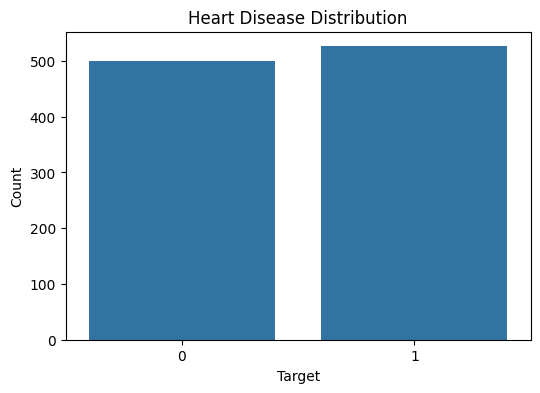

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x=df["target"])

plt.title("Heart Disease Distribution")

plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

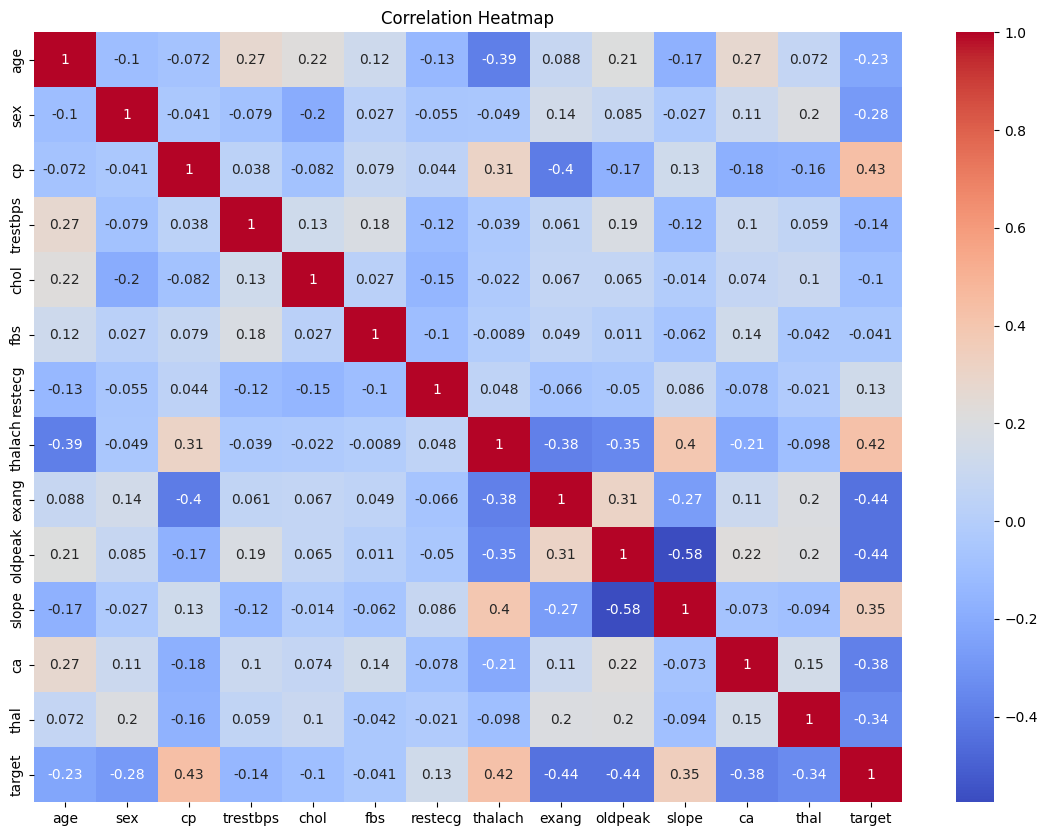

In [ ]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

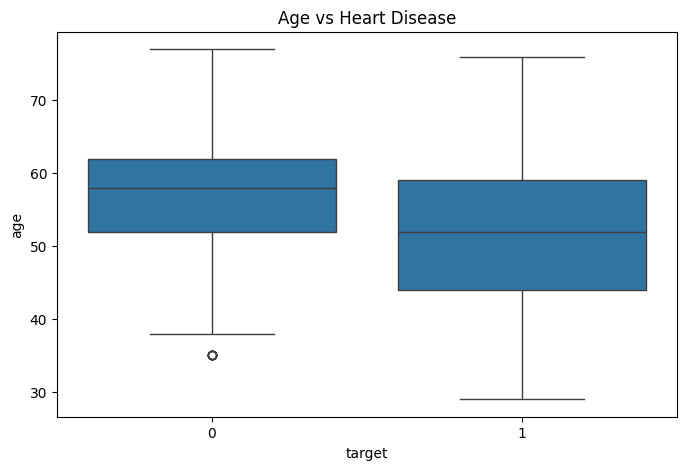

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["target"],
    y=df["age"])

plt.title("Age vs Heart Disease")

plt.show()

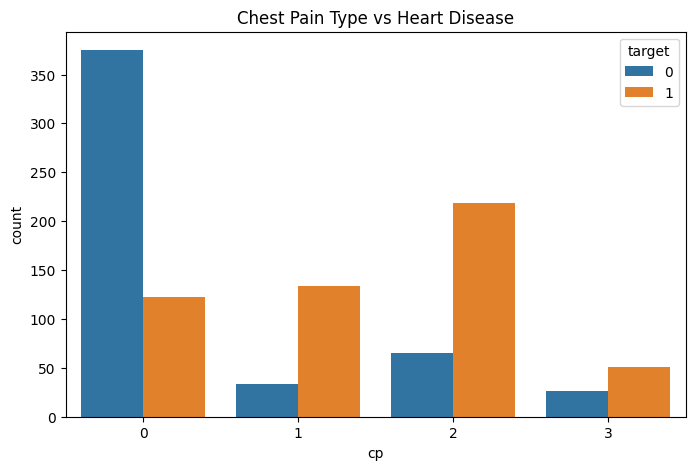

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=df["cp"],
    hue=df["target"])

plt.title("Chest Pain Type vs Heart Disease")

plt.show()

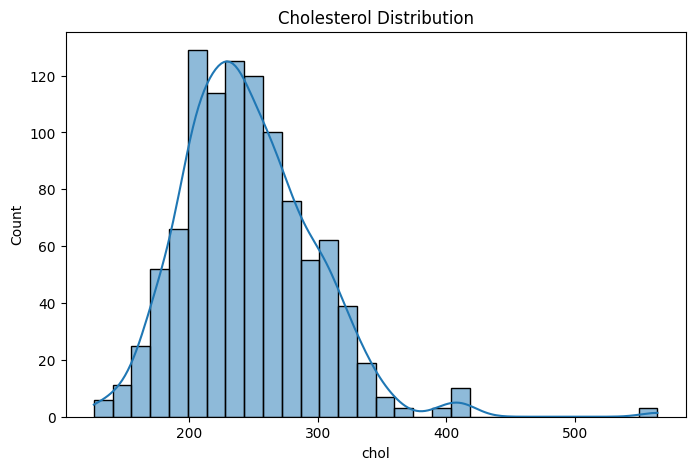

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["chol"],
    bins=30,
    kde=True)

plt.title("Cholesterol Distribution")

plt.show()

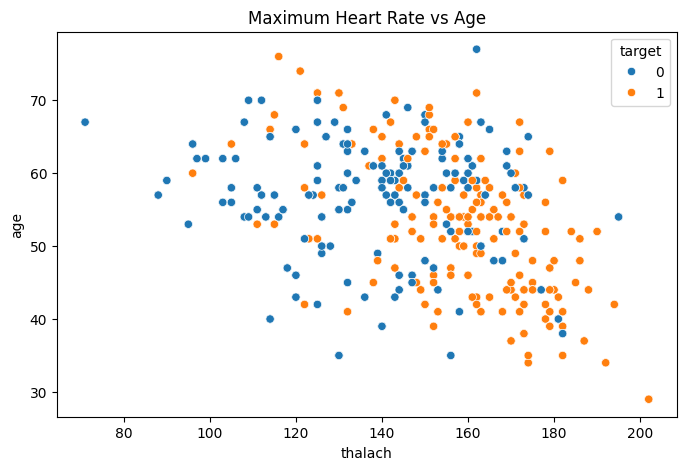

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["thalach"],
    y=df["age"],
    hue=df["target"])

plt.title("Maximum Heart Rate vs Age")

plt.show()

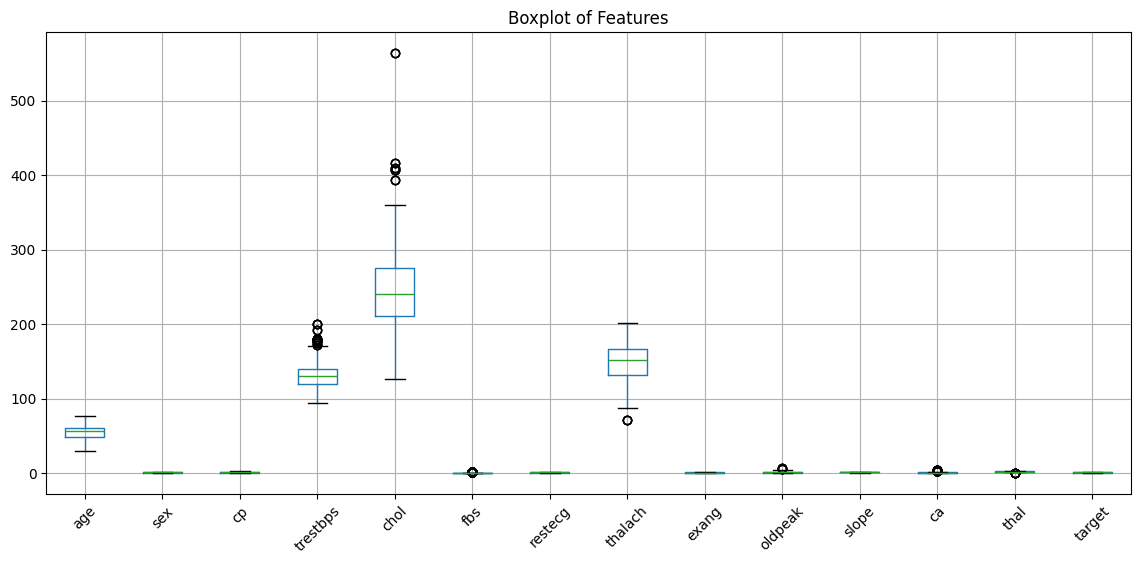

In [ ]:
plt.figure(figsize=(14,6))

df.boxplot()

plt.xticks(rotation=45)

plt.title("Boxplot of Features")

plt.show()

In [ ]:
### Uç verileri hesaba katmayalım
for col in ["chol", "trestbps", "oldpeak"]:

    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)

    df[col] = df[col].clip(lower, upper)

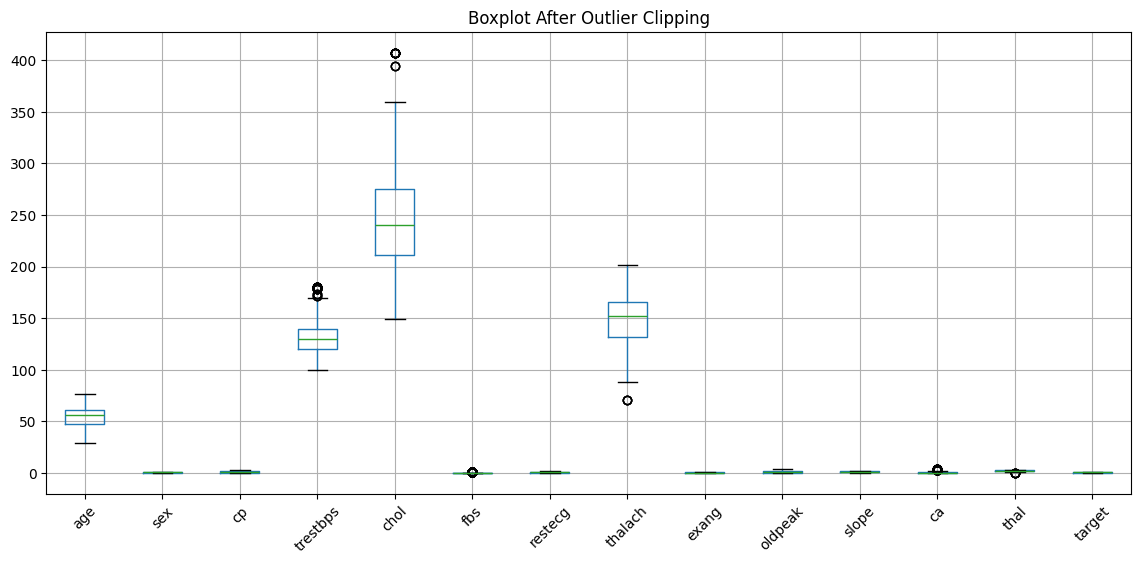

In [ ]:
### Yeni boxplot
plt.figure(figsize=(14,6))

df.boxplot()

plt.xticks(rotation=45)

plt.title("Boxplot After Outlier Clipping")

plt.show()

In [ ]:
X = df.drop("target", axis=1)

y = df["target"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier)

from xgboost import XGBClassifier

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score)

import pandas as pd

In [ ]:
models = {

    "Logistic Regression":
        LogisticRegression(),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42 ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=5,
            random_state=42)}

results = []

for model_name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    results.append({

        "Model": model_name,

        "Accuracy":
            accuracy_score(y_test, y_pred),

        "Precision":
            precision_score(y_test, y_pred),

        "Recall":
            recall_score(y_test, y_pred),

        "F1 Score":
            f1_score(y_test, y_pred)})

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.809756,0.761905,0.914286,0.831169
1,Decision Tree,0.985366,1.000000,0.971429,0.985507
2,Random Forest,1.000000,1.000000,1.000000,1.000000
3,Gradient Boosting,0.975610,0.971698,0.980952,0.976303
4,XGBoost,1.000000,1.000000,1.000000,1.000000


In [ ]:
df.duplicated().sum() ###sonuç gerçekçi değil(Data Leakage)

np.int64(723)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

df.shape

(302, 14)

In [ ]:
X = df.drop("target", axis=1)

y = df["target"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
models = {

    "Logistic Regression":
        LogisticRegression(),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=5,
            random_state=42
        )
}

results = []

for model_name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    results.append({

        "Model": model_name,

        "Accuracy":
            accuracy_score(y_test, y_pred),

        "Precision":
            precision_score(y_test, y_pred),

        "Recall":
            recall_score(y_test, y_pred),

        "F1 Score":
            f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.803279,0.800000,0.848485,0.823529
1,Decision Tree,0.803279,0.818182,0.818182,0.818182
2,Random Forest,0.754098,0.764706,0.787879,0.776119
3,Gradient Boosting,0.721311,0.735294,0.757576,0.746269
4,XGBoost,0.737705,0.757576,0.757576,0.757576


### Yeni Feature Set

In [ ]:
selected_features = [
    "cp",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal"]

X = df[selected_features]

y = df["target"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score)

lr_model = LogisticRegression()

lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("Recall:", recall_score(y_test, y_pred))

print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.7704918032786885
Precision: 0.7878787878787878
Recall: 0.7878787878787878
F1 Score: 0.7878787878787878


In [ ]:
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier)

from xgboost import XGBClassifier

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score)

import pandas as pd

In [ ]:
models = {

    "Logistic Regression":
        LogisticRegression(),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42 ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42),

    "XGBoost":
        XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=5,
            random_state=42)}

In [ ]:
results = []

for model_name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    results.append({

        "Model": model_name,

        "Accuracy":
            accuracy_score(y_test, y_pred),

        "Precision":
            precision_score(y_test, y_pred),

        "Recall":
            recall_score(y_test, y_pred),

        "F1 Score":
            f1_score(y_test, y_pred)})

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.770492,0.787879,0.787879,0.787879
1,Decision Tree,0.836066,0.828571,0.878788,0.852941
2,Random Forest,0.786885,0.794118,0.818182,0.805970
3,Gradient Boosting,0.770492,0.787879,0.787879,0.787879
4,XGBoost,0.754098,0.781250,0.757576,0.769231


In [ ]:
### Confusion Matrix
from sklearn.metrics import confusion_matrix

best_model = DecisionTreeClassifier(random_state=42)

best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

cm

array([[22,  6],
       [ 4, 29]])

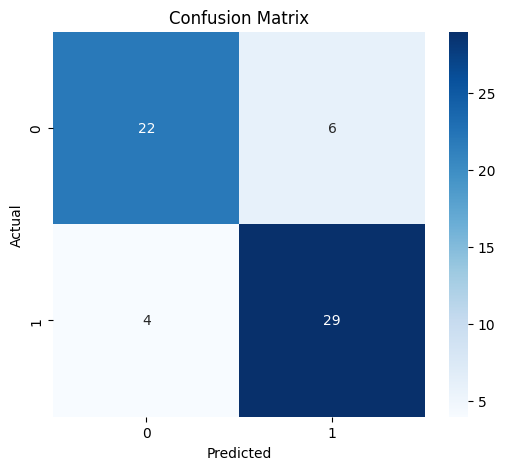

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

## Confusion Matrix Analysis

The confusion matrix demonstrates that the Decision Tree model performed well in distinguishing patients with and without heart disease.

### Results
- 22 healthy patients were correctly classified.
- 29 patients with heart disease were correctly identified.
- 6 healthy patients were incorrectly classified as having heart disease.
- 4 heart disease cases were missed by the model.

### Interpretation

The model achieved a balanced classification performance.

In medical applications, minimizing false negatives is especially important because missing a patient with heart disease may lead to serious consequences.

The relatively low number of false negatives indicates that the model is effective at identifying patients at risk.